In [114]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [166]:
df = pd.read_json('India-Food-Delivery-Time-Prediction.txt')
df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:33:33,11:45:29,conditions Sunny,High,2,Snack,motorcycle,0.0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:37,19:51:49,conditions Stormy,Jam,2,Snack,scooter,1.0,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:32:58,8:48:47,conditions Sandstorms,Low,0,Drinks,motorcycle,1.0,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:03:58,18:12:52,conditions Sunny,Medium,0,Buffet,motorcycle,1.0,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:34:16,13:45:36,conditions Cloudy,High,1,Snack,scooter,1.0,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41948,0x1178,RANCHIRES16DEL01,35.0,4.2,23.371292,85.327872,23.481292,85.437872,08-03-2022,21:47:47,21:59:27,conditions Windy,Jam,2,Drinks,motorcycle,1.0,No,Metropolitian,(min) 33
41949,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:36:22,11:48:07,conditions Windy,High,1,Meal,motorcycle,0.0,No,Metropolitian,(min) 32
41950,0x4f8d,CHENRES08DEL03,30.0,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:56,0:08:55,conditions Cloudy,Low,1,Drinks,scooter,0.0,No,Metropolitian,(min) 16
41951,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:40:13,13:42:00,conditions Cloudy,High,0,Snack,motorcycle,1.0,No,Metropolitian,(min) 26


In [167]:
print(df.shape)

(41953, 20)


### Types Of Datas
  **Numerical** Delivery_person_Age,  Delivery_person_Ratings, Restaurant_latitude, Restaurant_longitude, Delivery_location_latitude, Delivery_location_longitude.  
     
  **Categorical**   Order_Date, Time_Orderd, Time_Order_picked, Weatherconditions, Road_traffic_density, Type_of_order, Type_of_vehicle, Festival, City, Time_taken(min), Vehicle_condition, multiple_deliveries, Delivery_person_ID.  
    
  **Mixed**   ID.  

In [168]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 41953 entries, 0 to 41952
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           41953 non-null  str    
 1   Delivery_person_ID           41953 non-null  str    
 2   Delivery_person_Age          40234 non-null  float64
 3   Delivery_person_Ratings      40190 non-null  float64
 4   Restaurant_latitude          41953 non-null  float64
 5   Restaurant_longitude         41953 non-null  float64
 6   Delivery_location_latitude   41953 non-null  float64
 7   Delivery_location_longitude  41953 non-null  float64
 8   Order_Date                   41953 non-null  str    
 9   Time_Orderd                  40353 non-null  str    
 10  Time_Order_picked            41953 non-null  str    
 11  Weatherconditions            41953 non-null  str    
 12  Road_traffic_density         41953 non-null  str    
 13  Vehicle_condition          

In [169]:
print(df['Vehicle_condition'].value_counts())

Vehicle_condition
1    13851
0    13815
2    13806
3      481
Name: count, dtype: int64


In [170]:
print(df['Delivery_person_ID'].value_counts())

Delivery_person_ID
JAPRES11DEL02      67
PUNERES01DEL01     67
VADRES11DEL02      66
JAPRES03DEL01      66
HYDRES04DEL02      66
                   ..
AURGRES13DEL03      7
GOARES01DEL03       7
KOLRES09DEL03       6
KOCRES16DEL03       6
BHPRES010DEL03      5
Name: count, Length: 1170, dtype: int64


- Deliver_person_Ratings : Max Rating is 6 (i think this is outlier if rating is out of 5).


In [121]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries
count,40234.000000,40190.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41048.000000
mean,29.563330,4.632386,18.911397,76.923408,18.975064,76.987074,1.022716,0.745249
std,5.812361,0.335541,5.467829,3.502910,5.469616,3.503073,0.838893,0.572152
min,15.000000,1.000000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000
25%,25.000000,4.500000,12.986047,73.898520,13.065996,73.940327,0.000000,0.000000
50%,30.000000,4.700000,19.065838,76.618203,19.123249,76.663622,1.000000,1.000000
75%,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000


In [172]:
df.describe(include='all')

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
count,41953,41953,40234.000000,40190.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953,40353,41953,41953,41953,41953.000000,41953,41953,41048.000000,41953,41953,41953
unique,41953,1170,NaN,NaN,NaN,NaN,NaN,NaN,44,25569,26949,7,5,NaN,4,4,NaN,3,4,45
top,0x4607,JAPRES11DEL02,NaN,NaN,NaN,NaN,NaN,NaN,15-03-2022,20:32:38,0:00:12,conditions Fog,Low,NaN,Snack,motorcycle,NaN,No,Metropolitian,(min) 26
freq,1,67,NaN,NaN,NaN,NaN,NaN,NaN,1115,8,8,7012,14200,NaN,10616,24396,NaN,40916,31411,1960
mean,NaN,NaN,29.563330,4.632386,18.911397,76.923408,18.975064,76.987074,NaN,NaN,NaN,NaN,NaN,1.022716,NaN,NaN,0.745249,NaN,NaN,NaN
std,NaN,NaN,5.812361,0.335541,5.467829,3.502910,5.469616,3.503073,NaN,NaN,NaN,NaN,NaN,0.838893,NaN,NaN,0.572152,NaN,NaN,NaN
min,NaN,NaN,15.000000,1.000000,9.957144,72.768726,9.967144,72.778726,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN
25%,NaN,NaN,25.000000,4.500000,12.986047,73.898520,13.065996,73.940327,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN
50%,NaN,NaN,30.000000,4.700000,19.065838,76.618203,19.123249,76.663622,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN
75%,NaN,NaN,35.000000,4.900000,22.751234,78.368855,22.820040,78.405467,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,NaN,1.000000,NaN,NaN,NaN


- These 4 columns have null values.

In [173]:
print(df.isnull().sum())

ID                                0
Delivery_person_ID                0
Delivery_person_Age            1719
Delivery_person_Ratings        1763
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             905
Festival                          0
City                              0
Time_taken(min)                   0
dtype: int64


**NaN Values are present but few percentage out of total percentage values.
So, we will fill these null values by Mode(most frquently value).**

In [174]:
df['Road_traffic_density'].value_counts()

Road_traffic_density
Low        14200
Jam        13043
Medium     10084
High        4071
NaN          555
Name: count, dtype: int64

In [175]:
df['Road_traffic_density']= df['Road_traffic_density'].fillna(df['Road_traffic_density'].mode()[0])
df['Road_traffic_density'].value_counts()

Road_traffic_density
Low        14200
Jam        13043
Medium     10084
High        4071
NaN          555
Name: count, dtype: int64

-- Hidden Space is also presnt {"High "}. So, we will remove the hidden space by strip function.

In [176]:
df['Road_traffic_density'].unique()

<StringArray>
['High ', 'Jam ', 'Low ', 'Medium ', 'NaN ']
Length: 5, dtype: str

In [177]:
df['Road_traffic_density'] = df['Road_traffic_density'].str.strip()
df['Road_traffic_density'].unique()

<StringArray>
['High', 'Jam', 'Low', 'Medium', 'NaN']
Length: 5, dtype: str

In [178]:
df['Road_traffic_density']= df['Road_traffic_density'].replace("NaN",np.nan)
df['Road_traffic_density']= df['Road_traffic_density'].fillna(df['Road_traffic_density'].mode()[0])

df['Road_traffic_density'].value_counts()

Road_traffic_density
Low       14755
Jam       13043
Medium    10084
High       4071
Name: count, dtype: int64

<Axes: >

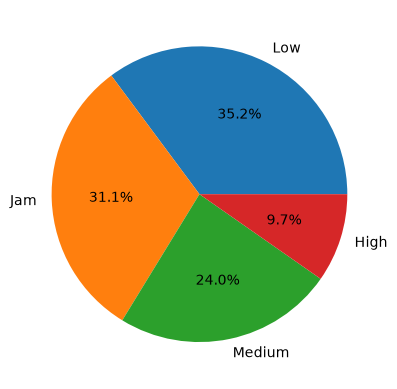

In [246]:
df['Road_traffic_density'].value_counts().plot(kind='pie', autopct='%0.1f%%')

### Types_of_order
   **All orders are approximately equally distributed(i.e. Near 10000).**


In [179]:
df['Type_of_order'].value_counts()

Type_of_order
Snack      10616
Meal       10524
Drinks     10445
Buffet     10368
Name: count, dtype: int64

<Axes: >

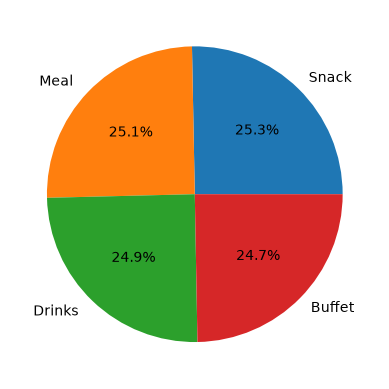

In [247]:
df['Type_of_order'].value_counts().plot(kind='pie', autopct='%0.1f%%')

### Type_of_vehicle
 --- Hidden spaces present.

In [180]:
df['Type_of_vehicle'].value_counts()

Type_of_vehicle
motorcycle           24396
scooter              14029
electric_scooter      3468
bicycle                 60
Name: count, dtype: int64

In [248]:
df['Type_of_vehicle'].unique()

<StringArray>
['motorcycle ', 'scooter ', 'electric_scooter ', 'bicycle ']
Length: 4, dtype: str

In [251]:
df['Type_of_vehicle'] = df['Type_of_vehicle'].str.strip()
df['Type_of_vehicle'].unique()

<StringArray>
['motorcycle', 'scooter', 'electric_scooter', 'bicycle']
Length: 4, dtype: str

<Axes: >

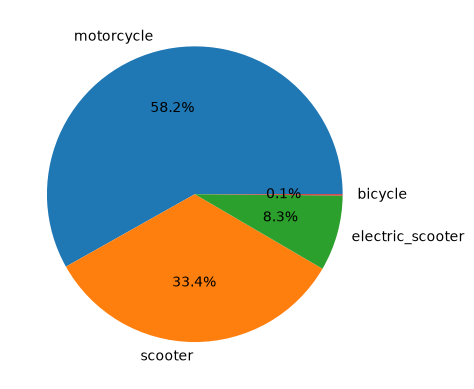

In [252]:
df['Type_of_vehicle'].value_counts().plot(kind='pie', autopct='%0.1f%%')

### City
   **NaN values are present.**  
   -- Hidden spaces present.  
   -- NaN is a string here not actual nan value.  
   -- Fill NaN Value by Mode.  

In [181]:
df['City'].unique()

<StringArray>
['Urban ', 'Metropolitian ', 'NaN ', 'Semi-Urban ']
Length: 4, dtype: str

In [182]:
df['City'].value_counts()

City
Metropolitian     31411
Urban              9279
NaN                1114
Semi-Urban          149
Name: count, dtype: int64

In [ ]:
df['City'] = df['City'].str.strip()
df['City']=df['City'].replace("NaN",np.nan)

df['City']= df['City'].fillna(df['City'].mode()[0])
df['City'].value_counts()

City
Metropolitian    32525
Urban             9279
Semi-Urban         149
Name: count, dtype: int64

<Axes: >

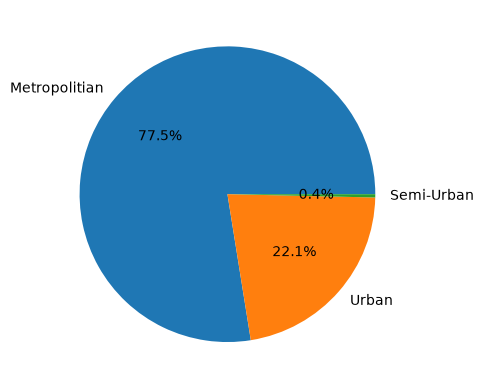

In [253]:
df['City'].value_counts().plot(kind='pie', autopct='%0.1f%%')

### Delivery_person_Ratings 
    -- 6.0 is an outlier and this is not genuine (if rating is out of 5.0).  
    -- nan values are also present.

<Axes: >

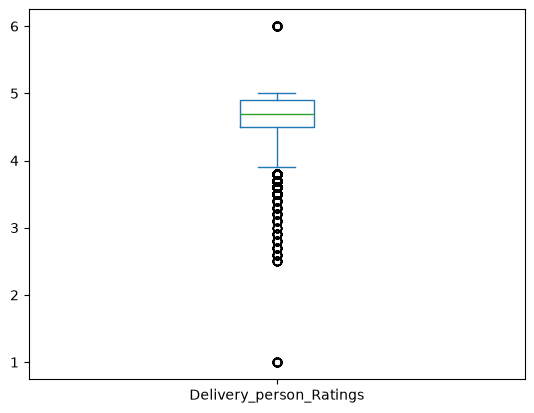

In [184]:
df['Delivery_person_Ratings'].plot(kind='box')

In [185]:
df[df['Delivery_person_Ratings']>5.0]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
3283,0x46d,BANGRES05DEL01,50.0,6.0,12.970324,77.645748,13.010324,77.685748,13-03-2022,NaN,12:34:56,conditions NaN,Low,3,Meal,electric_scooter,0.0,No,Urban,(min) 25
4315,0x493,HYDRES17DEL01,50.0,6.0,17.451976,78.385883,17.561976,78.495883,04-04-2022,NaN,23:23:19,conditions NaN,Low,3,Snack,bicycle,0.0,No,Metropolitian,(min) 27
4733,0x4f2,JAPRES08DEL01,50.0,6.0,26.910262,75.783013,27.020262,75.893013,18-03-2022,NaN,18:52:30,conditions NaN,Low,3,Drinks,scooter,1.0,No,Metropolitian,(min) 20
4909,0x430,BANGRES19DEL01,50.0,6.0,12.914264,77.678400,13.024264,77.788400,06-04-2022,NaN,20:59:52,conditions NaN,Low,3,Meal,electric_scooter,1.0,No,Metropolitian,(min) 18
5174,0xbef1,AGRRES13DEL02,50.0,6.0,27.159795,78.042990,27.209795,78.092990,13-02-2022,NaN,18:05:26,conditions NaN,Low,3,Drinks,scooter,1.0,No,Metropolitian,(min) 20
5867,0x427,JAPRES06DEL02,50.0,6.0,26.911927,75.797282,27.041927,75.927282,02-04-2022,NaN,22:14:35,conditions NaN,Low,3,Meal,electric_scooter,0.0,No,Urban,(min) 20
6457,0x3eb,MYSRES15DEL02,50.0,6.0,12.352058,76.606650,12.372058,76.626650,15-03-2022,NaN,10:00:43,conditions NaN,Low,3,Buffet,scooter,1.0,No,Metropolitian,(min) 14
8735,0x3f0,BANGRES010DEL01,50.0,6.0,12.933298,77.614293,13.003298,77.684293,12-03-2022,NaN,18:26:04,conditions NaN,Low,3,Drinks,scooter,1.0,No,Urban,(min) 17
8769,0x3ef,RANCHIRES13DEL01,50.0,6.0,23.374989,85.335486,23.444989,85.405486,20-03-2022,NaN,17:58:31,conditions NaN,Low,3,Snack,bicycle,1.0,No,Metropolitian,(min) 32
9291,0x5b0,MYSRES04DEL01,50.0,6.0,12.308500,76.665808,12.418500,76.775808,18-03-2022,NaN,20:10:58,conditions NaN,Low,3,Snack,electric_scooter,1.0,No,Metropolitian,(min) 35


In [186]:
df['Delivery_person_Ratings']=df['Delivery_person_Ratings'].clip(lower=1.0, upper=5.0)
print(df['Delivery_person_Ratings'].value_counts())

Delivery_person_Ratings
4.8    6558
4.7    6528
4.9    6468
4.6    6387
5.0    3712
4.5    3067
4.2    1331
4.1    1323
4.3    1301
4.4    1246
4.0     998
3.5     236
3.8     218
3.7     203
3.6     194
3.9     176
1.0      35
3.4      32
3.1      28
3.2      26
3.3      23
2.7      21
2.6      20
2.5      18
2.9      18
2.8      17
3.0       6
Name: count, dtype: int64


In [187]:
df['Delivery_person_Ratings'].describe()

count    40190.000000
mean         4.631242
std          0.332566
min          1.000000
25%          4.500000
50%          4.700000
75%          4.900000
max          5.000000
Name: Delivery_person_Ratings, dtype: float64

In [188]:
df['Delivery_person_Ratings'].isna().sum()

np.int64(1763)

In [189]:
df['Delivery_person_Ratings']=df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median())
df['Delivery_person_Ratings'].isna().sum()

np.int64(0)

### Delivery_person_Age 
   *** nan is present.***  
   --- change  the datatype float to int64.  
   -- Genuine Outlier present.


In [190]:
df['Delivery_person_Age'].unique()

array([37., 34., 23., 38., 32., 22., 33., 35., 36., 21., 24., 29., 25.,
       31., 27., 26., 20., nan, 28., 39., 30., 15., 50.])

In [191]:
df['Delivery_person_Age'].dtype

dtype('float64')

In [192]:

df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(round(df['Delivery_person_Age'].mean()))
df['Delivery_person_Age'] = df['Delivery_person_Age'].astype(int)
df['Delivery_person_Age'].unique()

array([37, 34, 23, 38, 32, 22, 33, 35, 36, 21, 24, 29, 25, 31, 27, 26, 20,
       30, 28, 39, 15, 50])

<Axes: >

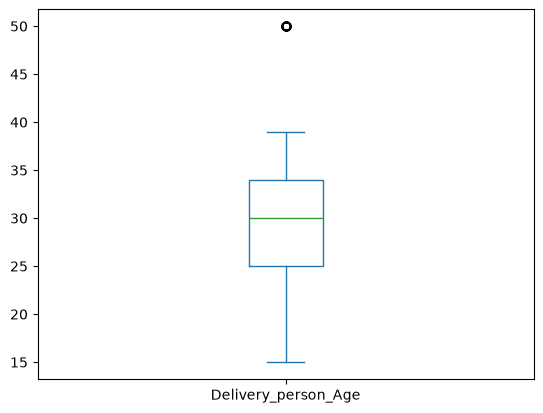

In [256]:
df['Delivery_person_Age'].plot(kind='box')

### Weatherconditions
  -- conditions NaN is present. (Filled By Mode)
  -- All Categorical values are using string "conditions". I removed it and make changes in original dataframe.

In [193]:
df['Weatherconditions'].unique()

<StringArray>
[     'conditions Sunny',     'conditions Stormy', 'conditions Sandstorms',
     'conditions Cloudy',        'conditions Fog',      'conditions Windy',
        'conditions NaN']
Length: 7, dtype: str

In [194]:
df['Weatherconditions'].value_counts()

Weatherconditions
conditions Fog           7012
conditions Stormy        6974
conditions Cloudy        6932
conditions Sandstorms    6906
conditions Windy         6832
conditions Sunny         6728
conditions NaN            569
Name: count, dtype: int64

In [195]:
df['Weatherconditions'].unique()

<StringArray>
[     'conditions Sunny',     'conditions Stormy', 'conditions Sandstorms',
     'conditions Cloudy',        'conditions Fog',      'conditions Windy',
        'conditions NaN']
Length: 7, dtype: str

In [196]:
df['Weatherconditions'] = df['Weatherconditions'].str.split(" ").str[1]
df['Weatherconditions'].value_counts()

Weatherconditions
Fog           7012
Stormy        6974
Cloudy        6932
Sandstorms    6906
Windy         6832
Sunny         6728
NaN            569
Name: count, dtype: int64

In [197]:
df['Weatherconditions'] = df['Weatherconditions'].replace("NaN",np.nan)
df['Weatherconditions'] = df['Weatherconditions'].fillna(df['Weatherconditions'].mode()[0])
df['Weatherconditions'].value_counts()

Weatherconditions
Fog           7581
Stormy        6974
Cloudy        6932
Sandstorms    6906
Windy         6832
Sunny         6728
Name: count, dtype: int64

<Axes: >

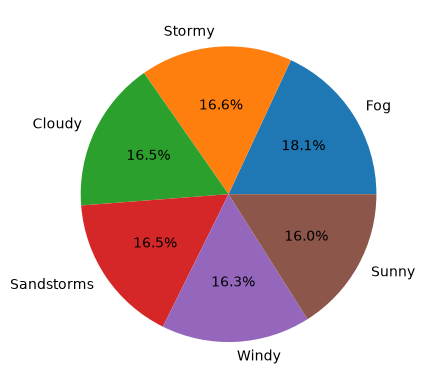

In [258]:
df['Weatherconditions'].value_counts().plot(kind='pie',autopct='%0.1f%%')

### Festival
  -- NaN Values present.  
  -- Hidden spaces also.

In [198]:
df['Festival'].value_counts()

Festival
No      40916
Yes       822
NaN       215
Name: count, dtype: int64

In [199]:
df['Festival'].unique()

<StringArray>
['No ', 'Yes ', 'NaN ']
Length: 3, dtype: str

In [200]:
df['Festival'] = df['Festival'].str.strip()
df['Festival'] = df['Festival'].replace("NaN",np.nan)
df['Festival'] = df['Festival'].fillna(df['Festival'].mode()[0])
df['Festival'].value_counts()

Festival
No     41131
Yes      822
Name: count, dtype: int64

<Axes: >

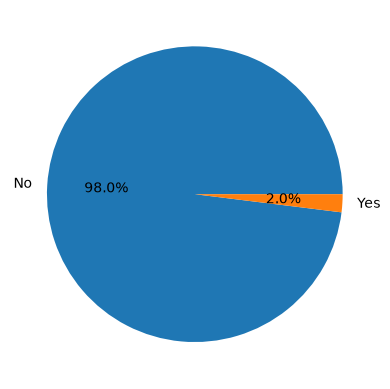

In [259]:
df['Festival'].value_counts().plot(kind='pie',autopct='%0.1f%%')

### Time_taken(min)
  -- Modify (deleting string : '(min)').  
  --- Outliers present but these outliers are genuine.

In [201]:
df['Time_taken(min)'].unique()

<StringArray>
['(min) 24', '(min) 33', '(min) 26', '(min) 21', '(min) 30', '(min) 40',
 '(min) 32', '(min) 34', '(min) 46', '(min) 23', '(min) 20', '(min) 41',
 '(min) 15', '(min) 36', '(min) 39', '(min) 18', '(min) 38', '(min) 47',
 '(min) 12', '(min) 22', '(min) 25', '(min) 10', '(min) 19', '(min) 11',
 '(min) 28', '(min) 52', '(min) 16', '(min) 27', '(min) 17', '(min) 14',
 '(min) 37', '(min) 44', '(min) 42', '(min) 31', '(min) 13', '(min) 29',
 '(min) 49', '(min) 35', '(min) 50', '(min) 48', '(min) 43', '(min) 54',
 '(min) 53', '(min) 45', '(min) 51']
Length: 45, dtype: str

In [204]:
df['Time_taken(min)'] = df['Time_taken(min)'].str.split(" ").str[-1].astype(int)
df['Time_taken(min)']

0        24
1        33
2        26
3        21
4        30
         ..
41948    33
41949    32
41950    16
41951    26
41952    36
Name: Time_taken(min), Length: 41953, dtype: int64

<Axes: >

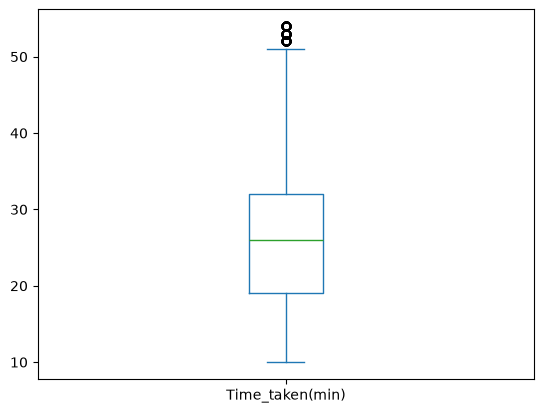

In [260]:
df['Time_taken(min)'].plot(kind='box')

### multiple_deliveries
  --- Nan values is present.  
  --- Convert float datatype to int datatype.

In [206]:
df['multiple_deliveries'].unique()

array([ 0.,  1.,  3., nan,  2.])

In [213]:
df['multiple_deliveries'] = df['multiple_deliveries'].fillna(df['multiple_deliveries'].mode()[0])
df['multiple_deliveries']

0        0.0
1        1.0
2        1.0
3        1.0
4        1.0
        ... 
41948    1.0
41949    0.0
41950    0.0
41951    1.0
41952    1.0
Name: multiple_deliveries, Length: 41953, dtype: float64

In [212]:
df['multiple_deliveries'].unique()

array([0., 1., 3., 2.])

In [217]:
df['multiple_deliveries'] = df['multiple_deliveries'].astype(int)
df['multiple_deliveries']

0        0
1        1
2        1
3        1
4        1
        ..
41948    1
41949    0
41950    0
41951    1
41952    1
Name: multiple_deliveries, Length: 41953, dtype: int64

<Axes: >

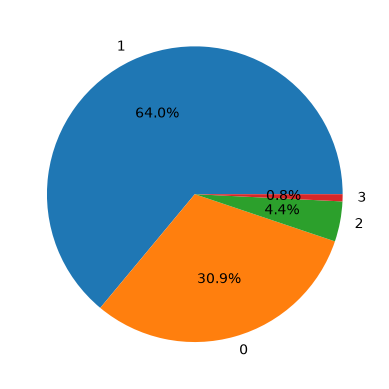

In [262]:
df['multiple_deliveries'].value_counts().plot(kind='pie',autopct='%0.1f%%')

### Vehicle_condition


In [219]:
df['Vehicle_condition'].unique()

array([2, 0, 1, 3])

In [220]:
df['Vehicle_condition'].isna().sum()

np.int64(0)

<Axes: >

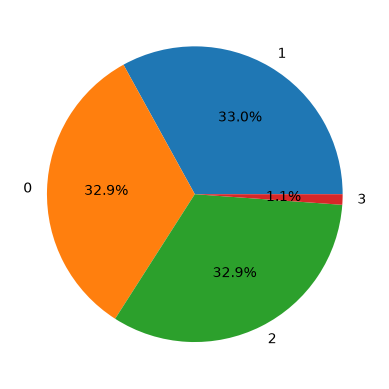

In [263]:
df['Vehicle_condition'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [222]:
df.isna().sum()

ID                                0
Delivery_person_ID                0
Delivery_person_Age               0
Delivery_person_Ratings           0
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1600
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density              0
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries               0
Festival                          0
City                              0
Time_taken(min)                   0
dtype: int64

### Time_Orderd
  --- nan values removed.  
  --- Outliers present (but these outliers maybe geniune).

In [223]:
df['Time_Orderd'].unique()

<StringArray>
['11:33:33', '19:45:37',  '8:32:58', '18:03:58', '13:34:16', '21:23:28',
 '19:19:19', '17:29:18', '20:56:37', '21:59:01',
 ...
  '9:30:56', '18:41:49', '21:45:11', '10:30:12',  '9:15:33',  '9:05:13',
 '21:14:51', '21:47:47', '23:50:56', '17:12:55']
Length: 25570, dtype: str

In [224]:
df['Time_Orderd'] = df['Time_Orderd'].fillna(df['Time_Orderd'].mode()[0])
df['Time_Orderd']

0        11:33:33
1        19:45:37
2         8:32:58
3        18:03:58
4        13:34:16
           ...   
41948    21:47:47
41949    11:36:22
41950    23:50:56
41951    13:40:13
41952    17:12:55
Name: Time_Orderd, Length: 41953, dtype: str

In [225]:
df['Time_Orderd'].isna().sum()

np.int64(0)

In [236]:
df.isna().sum()

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64

In [235]:
df[df['Time_taken(min)']>50]

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
42,0xb796,SURRES17DEL03,37,4.7,21.149569,72.772697,21.239569,72.862697,04-04-2022,19:49:09,19:53:08,Sandstorms,Jam,0,Snack,motorcycle,3,No,Metropolitian,52
171,0x4b5b,MYSRES04DEL03,38,4.3,12.308500,76.665808,12.398500,76.755808,04-04-2022,21:19:48,21:27:42,Sandstorms,Jam,0,Meal,motorcycle,1,Yes,Semi-Urban,54
244,0xd92f,AGRRES03DEL01,35,4.9,27.160832,78.011608,27.230832,78.081608,18-02-2022,21:17:31,21:30:07,Cloudy,Jam,0,Buffet,motorcycle,2,No,Metropolitian,53
586,0xc2ba,LUDHRES18DEL03,20,3.9,30.890184,75.829615,30.950184,75.889615,11-02-2022,20:44:03,20:45:45,Sunny,Jam,0,Buffet,motorcycle,1,No,Metropolitian,54
659,0x836d,HYDRES06DEL01,31,4.4,17.455894,78.375467,17.525894,78.445467,25-03-2022,19:37:56,19:43:09,Stormy,Jam,0,Meal,motorcycle,1,Yes,Metropolitian,53
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41599,0x5ff8,MYSRES03DEL03,39,4.1,12.299524,76.642620,12.389524,76.732620,23-03-2022,20:55:59,21:06:01,Sandstorms,Jam,0,Drinks,motorcycle,3,No,Metropolitian,51
41622,0x5df8,HYDRES08DEL02,35,4.9,17.438263,78.397865,17.568263,78.527865,02-03-2022,20:37:15,20:42:54,Cloudy,Jam,0,Drinks,motorcycle,1,No,Semi-Urban,51
41680,0x713d,JAPRES07DEL02,39,4.4,26.766536,75.837333,26.896536,75.967333,18-03-2022,21:39:02,21:48:59,Sandstorms,Jam,0,Drinks,motorcycle,1,No,Metropolitian,53
41691,0x2271,SURRES19DEL01,35,4.7,21.149669,72.772629,21.219669,72.842629,23-03-2022,20:45:26,21:03:42,Cloudy,Jam,0,Meal,motorcycle,1,No,Metropolitian,51


In [232]:
df.sample(10)

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
5702,0x7ee3,CHENRES07DEL01,30,4.6,13.081878,80.248519,13.151878,80.318519,04-04-2022,20:15:59,20:32:52,Cloudy,Jam,0,Snack,motorcycle,2,No,Metropolitian,44
8138,0x6a30,JAPRES14DEL02,28,4.6,26.888420,75.800689,26.908420,75.820689,03-04-2022,9:29:33,9:37:40,Sandstorms,Low,1,Buffet,motorcycle,1,No,Metropolitian,17
29235,0x5bc2,SURRES02DEL02,36,4.7,21.186608,72.794136,21.316608,72.924136,12-03-2022,23:12:10,23:19:03,Sunny,Low,2,Drinks,scooter,1,No,Metropolitian,20
2549,0x7f5c,MUMRES02DEL01,28,4.8,19.221315,72.862381,19.331315,72.972381,31-03-2022,23:44:02,23:59:42,Cloudy,Low,2,Drinks,scooter,1,No,Metropolitian,28
6601,0xd960,KOLRES13DEL02,34,4.0,22.553227,88.353273,22.633227,88.433273,18-02-2022,22:26:13,22:42:08,Cloudy,Low,0,Meal,motorcycle,0,No,Metropolitian,42
10363,0x8f61,COIMBRES08DEL01,36,4.7,11.001852,76.976268,11.111852,77.086268,18-03-2022,20:49:20,20:50:03,Cloudy,Jam,0,Snack,motorcycle,0,No,Metropolitian,44
16932,0x22aa,MUMRES02DEL01,25,4.9,19.221315,72.862381,19.261315,72.902381,13-03-2022,14:21:38,14:27:34,Sandstorms,High,0,Drinks,motorcycle,0,No,Metropolitian,24
7572,0x9226,CHENRES03DEL03,24,4.7,13.091809,80.219104,13.151809,80.279104,26-03-2022,17:39:33,17:54:57,Windy,Medium,2,Buffet,motorcycle,1,No,Metropolitian,28
11249,0xb846,CHENRES010DEL03,35,4.7,13.066762,80.251865,13.126762,80.311865,09-03-2022,20:26:21,20:34:31,Sunny,Jam,2,Drinks,scooter,1,No,Metropolitian,24
36451,0x6da5,INDORES05DEL02,32,3.9,22.727021,75.884167,22.857021,76.014167,29-03-2022,21:22:35,21:32:15,Windy,Jam,2,Drinks,scooter,0,No,Urban,38


### Restaurant_latitude , Restaurant_longitude, Delivery_location_latitude, Delivery_location_longitude
--- Outliers present in Restaurant_longitude and Delivery_location_longitude.
--- These are genuine outliers because the latitude is lies between the -90 to 90 and longitude is lies between -18- to 180.(latitude and Longitude have fixed valid range on Earth).



<Axes: >

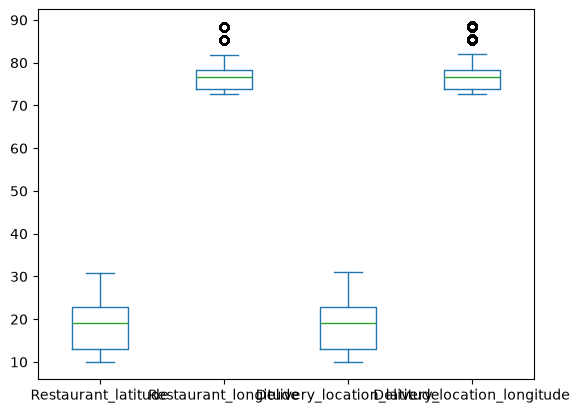

In [241]:
df[['Restaurant_latitude','Restaurant_longitude','Delivery_location_latitude', 'Delivery_location_longitude' ]].plot(kind='box', label=True)

In [242]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition,multiple_deliveries,Time_taken(min)
count,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000,41953.000000
mean,29.581222,4.634131,18.911397,76.923408,18.975064,76.987074,1.022716,0.750745,26.311539
std,5.692692,0.325795,5.467829,3.502910,5.469616,3.503073,0.838893,0.567156,9.380753
min,15.000000,1.000000,9.957144,72.768726,9.967144,72.778726,0.000000,0.000000,10.000000
25%,25.000000,4.500000,12.986047,73.898520,13.065996,73.940327,0.000000,0.000000,19.000000
50%,30.000000,4.700000,19.065838,76.618203,19.123249,76.663622,1.000000,1.000000,26.000000
75%,34.000000,4.800000,22.751234,78.368855,22.820040,78.405467,2.000000,1.000000,32.000000
max,50.000000,5.000000,30.914057,88.433452,31.054057,88.563452,3.000000,3.000000,54.000000


### Data Quality Issues (all now cleaned)
- Hidden whitespace in categorical fields (Road_traffic_density, Type_of_vehicle, City, Weatherconditions, Festival) — required .str.strip()  
- Fake "NaN" strings instead of actual null values in several columns  
- Missing values: Delivery_person_Age (1719), Delivery_person_Ratings (1763), Time_Orderd (1600), multiple_deliveries (905), Road_traffic_density (555), City (1114), Weatherconditions (569), Festival (215) - all imputed with mode/mean  
- Outlier in ratings: max rating was 6.0 despite a 1–5 scale (47 rows) — clipped to [1, 5]  
- Text prefixes needing extraction: "(min) 24" → 24, "conditions Sunny" → Sunny  

### Distributions
- Target (Time_taken): ranges 10–54 min, mean ≈ 26.3 min, std ≈ 9.4 min — roughly symmetric, no major skew
- Vehicle type: motorcycle dominates (~58%), then scooter (~33%), electric_scooter (~8%), bicycle negligible (~0.1%)
- City: Metropolitan area dominates (~77%), Urban ~22%, Semi-Urban is a tiny minority (~0.4%) — big class imbalance
- Order type: nearly evenly split across Snack/Meal/Drinks/Buffet (~25% each) — balanced feature
- Weather conditions: fairly even across Fog/Stormy/Cloudy/Sandstorms/Windy/Sunny (~14–18% each)
- Festival: heavily imbalanced — ~98% "No" vs ~2% "Yes"
- Multiple deliveries: mostly 0 or 1, values of 2–3 are rare
- Vehicle condition: mostly 0/1/2, value 3 is rare (~1%)

### Relationships to Explore Next
- Delivery_person_Age (15–50) and Delivery_person_Ratings (1.0–5.0, right-skewed toward high ratings) are likely predictive of delivery speed
- Since City, Festival, and Vehicle_condition==3 are heavily imbalanced, these features may need special handling (e.g., won't generalize well for rare categories) in modeling
- Geographic coordinates (Restaurant_latitude/longitude, Delivery_location_*) span all of India — you'll likely want to engineer a distance feature (haversine distance between restaurant and delivery location) rather than using raw lat/long directly, since raw coordinates aren't very informative for a regression model
- Order_Date, Time_Orderd, Time_Order_picked are still string/object dtypes — worth converting to datetime and possibly extracting features like day-of-week, hour-of-day, or the prep-time gap (Time_Order_picked - Time_Orderd)